# BFI-2 Personality Shift Analysis

This notebook analyzes how generative agents' **Big Five (BFI-2)** personality
profiles shift after "living" in different simulated school environments, each
modeled on a different political party's program (`afd`, `cdu`, `gruene`,
`spd`, `linke`), compared against a `base` measurement taken before any
environment exposure.

**Structure of the analysis:**

1. Load & combine all six result files
2. Compute per-agent shifts (environment − base) at the domain and facet level
3. **Group-level effects** — does an environment shift the *average* agent, and is that shift statistically significant?
4. **Individual-level effects** — how much do individual agents differ in how they respond to the same environment?
5. Radar plots for both group profiles and individual agents
6. Export tidy result tables and figures

> Adjust `FILE_PATHS` below to point at your actual files if the layout changes.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 1. Configuration

`FILE_PATHS` maps each run name to its CSV file. `base` is the pre-simulation
measurement; every other key is a post-simulation measurement under that
party's environment.


In [31]:
FILE_PATHS = {
    'base': '../../environment/frontend_server/storage/base/survey/bfi2_results_base.csv',
    'afd': '../../environment/frontend_server/storage/afd/survey/bfi2_results_afd.csv',
    'cdu': '../../environment/frontend_server/storage/cdu/survey/bfi2_results_cdu.csv',
    'gruene': (
        '../../environment/frontend_server/storage/gruene/survey/bfi2_results_gruene.csv'
    ),
    'spd': '../../environment/frontend_server/storage/spd/survey/bfi2_results_spd.csv',
    'linke': (
        '../../environment/frontend_server/storage/linke/survey/bfi2_results_linke.csv'
    ),
}

BASE_KEY = 'base'
ENV_KEYS = [k for k in FILE_PATHS if k != BASE_KEY]  # the 5 environments

# Column groups (edit here if your BFI-2 export ever adds/removes columns)
ID_COLS = ['persona_name', 'sim_time', 'party']

DOMAINS = [
    'domain_Extraversion',
    'domain_Agreeableness',
    'domain_Conscientiousness',
    'domain_Negative_Emotionality',
    'domain_Open-Mindedness',
]

FACETS = [
    'facet_Extraversion_Sociability',
    'facet_Extraversion_Assertiveness',
    'facet_Extraversion_Energy_Level',
    'facet_Agreeableness_Compassion',
    'facet_Agreeableness_Respectfulness',
    'facet_Agreeableness_Trust',
    'facet_Conscientiousness_Organization',
    'facet_Conscientiousness_Productiveness',
    'facet_Conscientiousness_Responsibility',
    'facet_Negative_Emotionality_Anxiety',
    'facet_Negative_Emotionality_Depression',
    'facet_Negative_Emotionality_Emotional_Volatility',
    'facet_Open-Mindedness_Aesthetic_Sensitivity',
    'facet_Open-Mindedness_Intellectual_Curiosity',
    'facet_Open-Mindedness_Creative_Imagination',
]

# Short, radar-friendly labels for the domains
DOMAIN_LABELS = {
    'domain_Extraversion': 'Extraversion',
    'domain_Agreeableness': 'Agreeableness',
    'domain_Conscientiousness': 'Conscientiousness',
    'domain_Negative_Emotionality': 'Neg. Emotionality',
    'domain_Open-Mindedness': 'Open-Mindedness',
}

# A fixed color per run so every plot uses the same palette
PARTY_COLORS = {
    'base':   '#7f7f7f',
    'afd':    '#009EE0',
    'cdu':    '#000000',
    'gruene': '#64A12D',
    'spd':    '#E3000F',
    'linke':  '#BE3075',
}


## 2. Load & combine data

Each CSV holds one row per agent for that run. The `party` column in the raw
files is typically empty, so we overwrite it with the dictionary key — that's
our reliable source of truth for which run a row belongs to.


In [3]:
def load_all(file_paths: dict) -> pd.DataFrame:
    frames = []
    for run_name, path in file_paths.items():
        if not os.path.exists(path):
            print(f"[WARN] Missing file for '{run_name}': {path}")
            continue
        df = pd.read_csv(path)
        df['party'] = run_name  # overwrite / fill in from the dict key
        frames.append(df)
    if not frames:
        raise FileNotFoundError(
            "None of the FILE_PATHS could be found. Check the paths / run "
            "this notebook from the right working directory."
        )
    combined = pd.concat(frames, ignore_index=True)
    combined['sim_time'] = pd.to_datetime(combined['sim_time'], errors='coerce')
    return combined


long_df = load_all(FILE_PATHS)
print(long_df.shape)
long_df.head()


(30, 23)


,persona_name,sim_time,party,domain_Extraversion,domain_Agreeableness,domain_Conscientiousness,domain_Negative_Emotionality,domain_Open-Mindedness,facet_Extraversion_Sociability,facet_Extraversion_Assertiveness,facet_Extraversion_Energy_Level,facet_Agreeableness_Compassion,facet_Agreeableness_Respectfulness,facet_Agreeableness_Trust,facet_Conscientiousness_Organization,facet_Conscientiousness_Productiveness,facet_Conscientiousness_Responsibility,facet_Negative_Emotionality_Anxiety,facet_Negative_Emotionality_Depression,facet_Negative_Emotionality_Emotional_Volatility,facet_Open-Mindedness_Aesthetic_Sensitivity,facet_Open-Mindedness_Intellectual_Curiosity,facet_Open-Mindedness_Creative_Imagination
0,Aylin Demir,2026-07-06 00:00:10,base,2.833,2.917,4.917,2.333,3.083,2.25,3.00,3.25,3.25,3.25,2.25,5.00,5.0,4.75,3.00,2.50,1.50,2.50,3.00,3.75
1,Katharina Weber,2026-07-06 00:00:10,base,2.417,3.250,4.667,2.500,2.583,1.50,3.00,2.75,3.25,4.25,2.25,4.75,4.5,4.75,4.00,2.50,1.00,2.25,3.00,2.50
2,Lukas Schneider,2026-07-06 00:00:10,base,2.250,3.000,3.417,2.500,2.500,2.25,1.75,2.75,3.00,3.50,2.50,3.75,3.0,3.50,2.75,2.75,2.00,3.00,2.25,2.25
3,Mohammed Idrissi,2026-07-06 00:00:10,base,2.417,3.167,1.917,2.917,2.583,2.50,2.25,2.50,3.25,3.25,3.00,1.75,2.0,2.00,3.00,2.50,3.25,2.25,2.25,3.25
4,Sofia Petrova,2026-07-06 00:00:10,base,3.750,3.500,2.167,3.250,3.500,4.25,3.75,3.25,4.25,2.75,3.50,2.00,2.5,2.00,3.50,2.25,4.00,3.25,3.75,3.50


In [4]:
# Sanity checks -------------------------------------------------------------
print("Runs loaded:", long_df['party'].unique().tolist())
print()
print("Agents per run:")
print(long_df.groupby('party')['persona_name'].nunique())

personas_per_run = long_df.groupby('party')['persona_name'].apply(set)
common_personas = set.intersection(*personas_per_run.values)
all_personas = set.union(*personas_per_run.values)

print(f"\n{len(common_personas)} agents appear in ALL runs (used for paired analysis).")
if common_personas != all_personas:
    missing = {
        run: all_personas - personas_per_run[run] for run in personas_per_run.index
    }
    print("Agents missing from at least one run:")
    for run, miss in missing.items():
        if miss:
            print(f"  {run}: {sorted(miss)}")

PERSONAS = sorted(common_personas)


Runs loaded: ['base', 'afd', 'cdu', 'gruene', 'spd', 'linke']

Agents per run:
party
afd       5
base      5
cdu       5
gruene    5
linke     5
spd       5
Name: persona_name, dtype: int64

5 agents appear in ALL runs (used for paired analysis).


## 3. Compute per-agent shifts

For every agent and every environment we compute `shift = environment_value -
base_value`, at both the domain and facet level. This gives us a tidy table
that drives everything downstream (paired stats, heatmaps, radar deltas).


In [5]:
SCORE_COLS = DOMAINS + FACETS

base_df = (
    long_df[long_df['party'] == BASE_KEY]
    .set_index('persona_name')[SCORE_COLS]
)

shift_records = []
for env in ENV_KEYS:
    env_df = (
        long_df[long_df['party'] == env]
        .set_index('persona_name')[SCORE_COLS]
    )
    shared = env_df.index.intersection(base_df.index)
    delta = env_df.loc[shared] - base_df.loc[shared]
    for persona in shared:
        for col in SCORE_COLS:
            shift_records.append({
                'persona_name': persona,
                'party': env,
                'measure': col,
                'level': 'domain' if col.startswith('domain_') else 'facet',
                'base_value': base_df.loc[persona, col],
                'env_value': env_df.loc[persona, col],
                'shift': delta.loc[persona, col],
            })

shift_df = pd.DataFrame(shift_records)
shift_df.head()


,persona_name,party,measure,level,base_value,env_value,shift
0,Aylin Demir,afd,domain_Extraversion,domain,2.833,3.250,0.417
1,Aylin Demir,afd,domain_Agreeableness,domain,2.917,3.250,0.333
2,Aylin Demir,afd,domain_Conscientiousness,domain,4.917,4.750,-0.167
3,Aylin Demir,afd,domain_Negative_Emotionality,domain,2.333,2.417,0.084
4,Aylin Demir,afd,domain_Open-Mindedness,domain,3.083,3.917,0.834


## 4. Group-level effects

### 4.1 Mean domain scores per run


In [6]:
group_means = (
    long_df[long_df['party'].isin([BASE_KEY] + ENV_KEYS)]
    # drop out teacher agent (Katharina Weber) from the mean calculation, since they are not part of the student population
    .query("persona_name != 'Katharina Weber'")
    .groupby('party')[DOMAINS]
    .mean()
    .reindex([BASE_KEY] + ENV_KEYS)
    .rename(columns=DOMAIN_LABELS)
)
group_means.round(3)


,Extraversion,Agreeableness,Conscientiousness,Neg. Emotionality,Open-Mindedness
party,,,,,
base,2.812,3.146,3.104,2.750,2.916
afd,3.250,3.479,3.479,2.604,3.688
cdu,3.188,3.438,3.458,2.646,3.562
gruene,3.188,3.500,3.500,2.500,3.562
spd,3.021,3.479,3.417,2.604,3.750
linke,3.104,3.708,3.416,2.437,3.688


### 4.2 Paired significance tests (environment vs. base)

For each environment × domain combination we run a **paired t-test** and the
non-parametric **Wilcoxon signed-rank test** (small samples benefit from
having both), plus paired Cohen's *d* as an effect size. Paired tests are
appropriate here because the *same* agents are measured before and after.


In [7]:
# remove Katharina Weber from the paired analysis, since she is not part of the student population
shift_df_stud = shift_df[shift_df['persona_name'] != 'Katharina Weber']

def cohens_d_paired(diffs: np.ndarray) -> float:
    diffs = np.asarray(diffs)
    sd = diffs.std(ddof=1)
    return diffs.mean() / sd if sd > 0 else np.nan


rows = []
for env in ENV_KEYS:
    for domain in DOMAINS:
        sub = shift_df_stud[
            (shift_df_stud['party'] == env) & (shift_df_stud['measure'] == domain)
        ]
        diffs = sub['shift'].values
        if len(diffs) < 2:
            continue
        t_stat, t_p = stats.ttest_rel(sub['env_value'], sub['base_value'])
        try:
            w_stat, w_p = stats.wilcoxon(diffs)
        except ValueError:
            w_stat, w_p = np.nan, np.nan
        rows.append({
            'party': env,
            'domain': DOMAIN_LABELS[domain],
            'n': len(diffs),
            'mean_shift': diffs.mean(),
            'sd_shift': diffs.std(ddof=1),
            'cohens_d': cohens_d_paired(diffs),
            't_stat': t_stat,
            't_pvalue': t_p,
            'wilcoxon_pvalue': w_p,
        })

group_stats = pd.DataFrame(rows)
group_stats['significant_p05'] = group_stats['t_pvalue'] < 0.05
group_stats.sort_values(['domain', 'party']).round(4)


,party,domain,n,mean_shift,sd_shift,cohens_d,t_stat,t_pvalue,wilcoxon_pvalue,significant_p05
1,afd,Agreeableness,4,0.3333,0.1359,2.4513,4.9026,0.0162,0.125,True
6,cdu,Agreeableness,4,0.2915,0.3504,0.8318,1.6636,0.1948,0.250,False
11,gruene,Agreeableness,4,0.3540,0.2188,1.6182,3.2364,0.0480,0.125,True
21,linke,Agreeableness,4,0.5623,0.1578,3.5626,7.1251,0.0057,0.125,True
16,spd,Agreeableness,4,0.3333,0.2453,1.3588,2.7176,0.0727,0.250,False
2,afd,Conscientiousness,4,0.3748,0.3880,0.9658,1.9316,0.1489,0.250,False
7,cdu,Conscientiousness,4,0.3540,0.4376,0.8089,1.6179,0.2041,0.250,False
12,gruene,Conscientiousness,4,0.3955,0.6506,0.6079,1.2159,0.3110,0.375,False
22,linke,Conscientiousness,4,0.3120,0.4378,0.7126,1.4253,0.2493,0.250,False
17,spd,Conscientiousness,4,0.3123,0.4157,0.7511,1.5022,0.2300,0.375,False


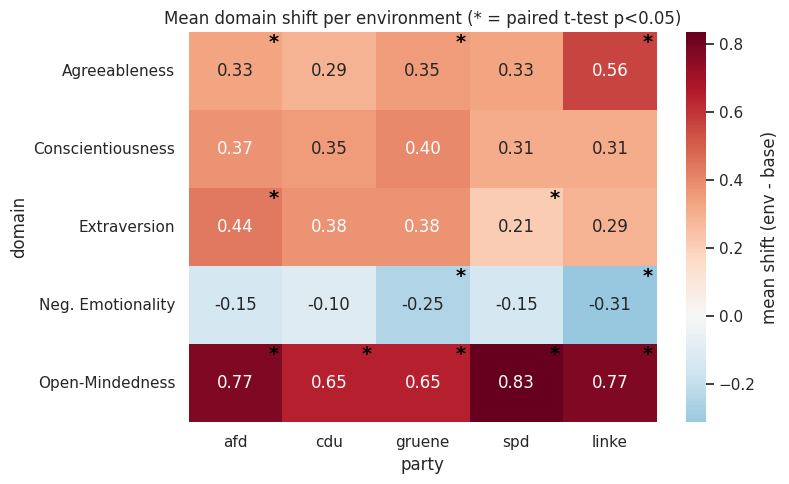

In [8]:
# Quick heatmap of mean shifts (group-level) with significance overlay
pivot_shift = group_stats.pivot(index='domain', columns='party', values='mean_shift')
pivot_sig = group_stats.pivot(index='domain', columns='party', values='significant_p05')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_shift.reindex(columns=ENV_KEYS),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
    cbar_kws={'label': 'mean shift (env - base)'}
)
# mark significant cells
for i, domain in enumerate(pivot_shift.index):
    for j, env in enumerate(ENV_KEYS):
        if pivot_sig.loc[domain, env]:
            ax.text(j + 0.85, i + 0.2, '*', color='black', fontsize=14, fontweight='bold')
ax.set_title("Mean domain shift per environment (* = paired t-test p<0.05)")
plt.tight_layout()
plt.show()


### 4.3 Group-level radar plot

Overlays the mean domain profile of every environment (plus base as a
reference) on a single radar chart.


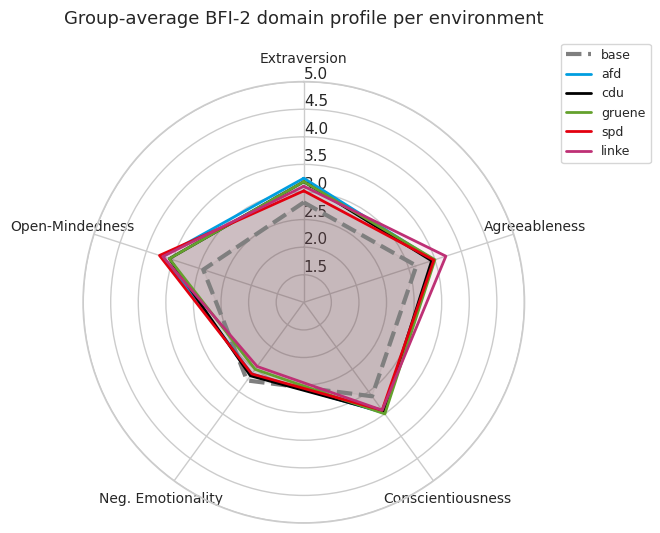

In [9]:
def radar_plot(categories, series: dict, colors=None, title="", ax=None,
                fill_alpha=0.08, value_range=(1, 5)):
    """Draw an overlaid radar chart.

    categories: list of axis labels
    series: dict of {label: list_of_values} (same order as categories)
    colors: optional dict of {label: color}
    """
    n = len(categories)
    angles = [i / n * 2 * np.pi for i in range(n)]
    angles += angles[:1]

    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(*value_range)
    ax.set_rlabel_position(0)
    ax.set_title(title, fontsize=13, pad=20)

    for label, values in series.items():
        vals = list(values) + [values[0]]
        color = colors.get(label) if colors else None
        lw = 3 if label == BASE_KEY else 2
        ls = '--' if label == BASE_KEY else '-'
        ax.plot(angles, vals, label=label, color=color, linewidth=lw, linestyle=ls)
        ax.fill(angles, vals, color=color, alpha=fill_alpha)

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
    if created_fig:
        plt.tight_layout()
    return ax


categories = [DOMAIN_LABELS[d] for d in DOMAINS]
series = {run: group_means.loc[run, categories].values for run in group_means.index}

radar_plot(
    categories, series, colors=PARTY_COLORS,
    title="Group-average BFI-2 domain profile per environment"
)
plt.show()


### 4.4 Group-level radar of *shifts* only

Same idea, but plotting the mean shift (env − base) per domain, centered on
zero, makes the direction and magnitude of each environment's effect easier
to compare directly.


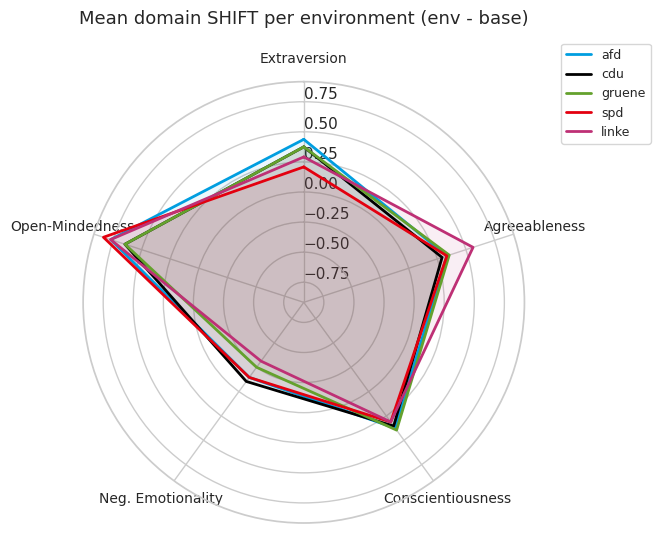

In [10]:
shift_categories = [DOMAIN_LABELS[d] for d in DOMAINS]
shift_series = {
    env: group_stats[group_stats['party'] == env]
         .set_index('domain').loc[shift_categories, 'mean_shift'].values
    for env in ENV_KEYS
}

max_abs = max(abs(v).max() for v in shift_series.values())
radar_plot(
    shift_categories, shift_series, colors=PARTY_COLORS,
    title="Mean domain SHIFT per environment (env - base)",
    value_range=(-max_abs * 1.1, max_abs * 1.1),
)
plt.show()


## 5. Individual-level effects

Group means can hide a lot: two agents can shift in opposite directions and
average out to "no effect". This section looks at each agent separately.

### 5.1 Individual radar grid — one panel per agent


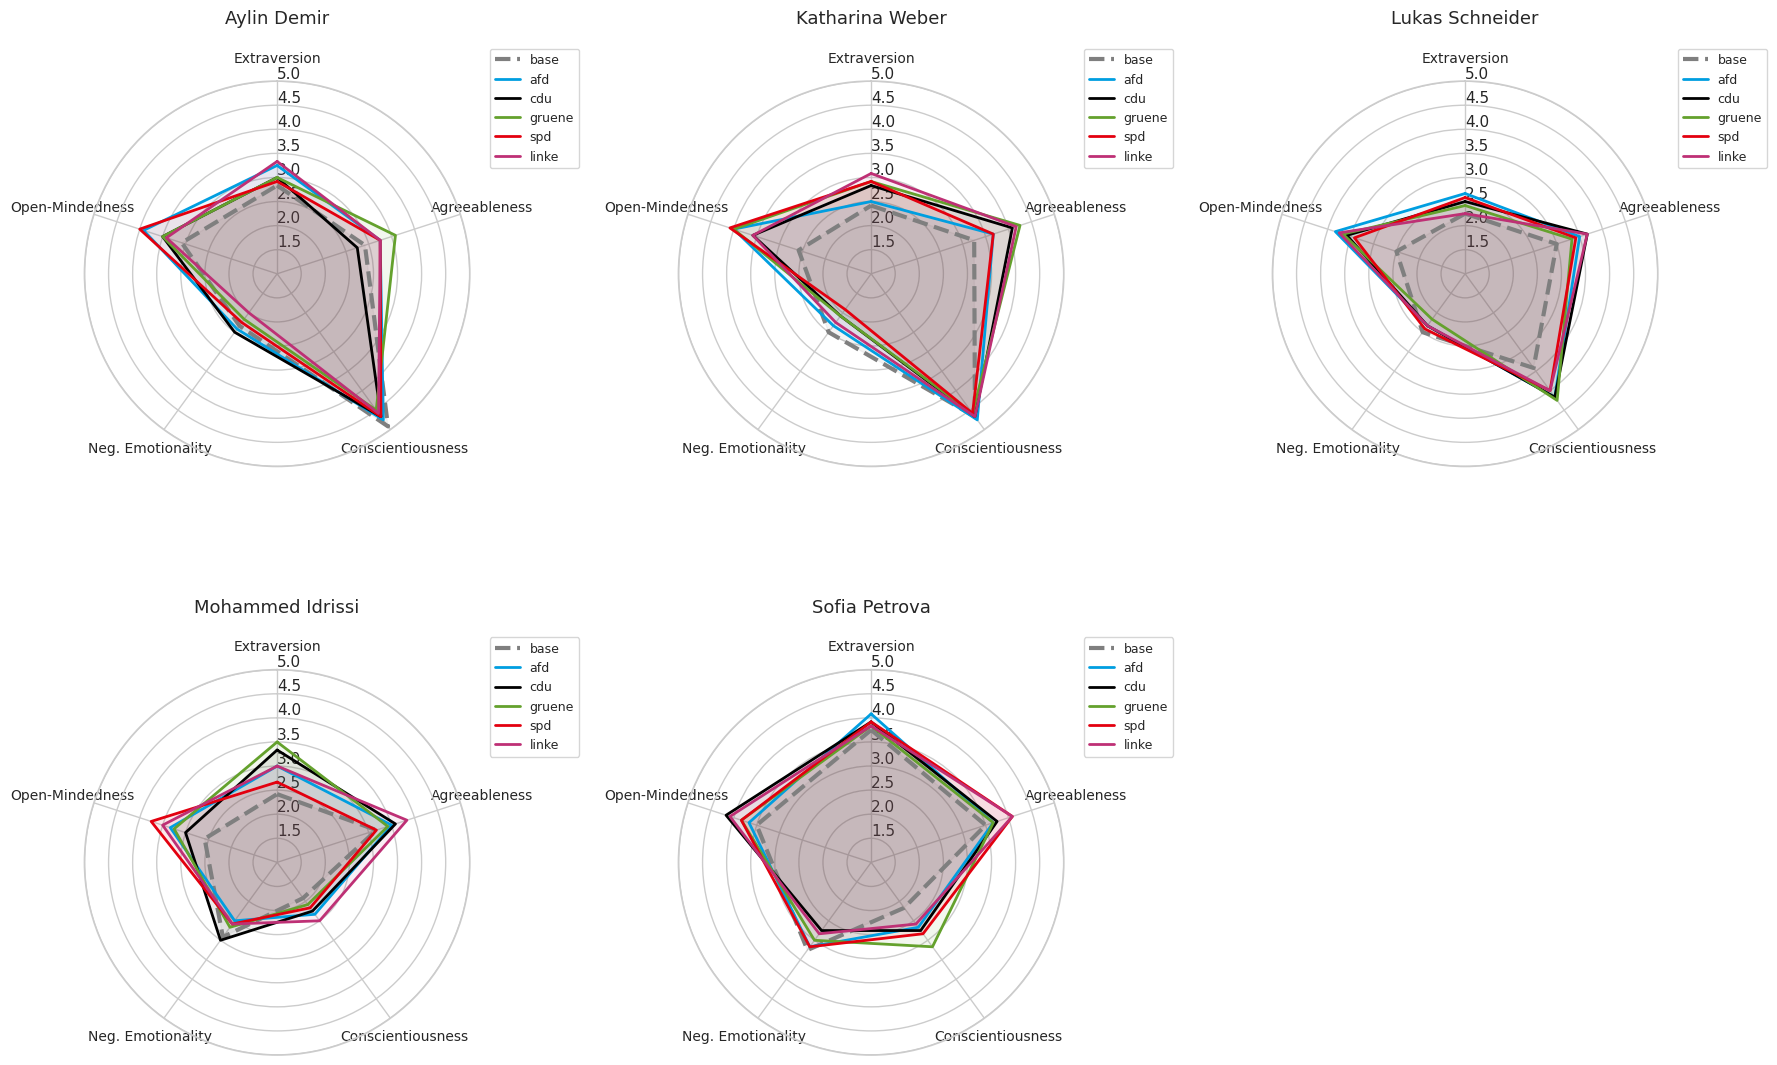

In [11]:
n_personas = len(PERSONAS)
n_cols = 3
n_rows = int(np.ceil(n_personas / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows),
    subplot_kw=dict(polar=True)
)
axes = np.atleast_1d(axes).flatten()

for ax, persona in zip(axes, PERSONAS):
    persona_rows = long_df[
        (long_df['persona_name'] == persona)
        & (long_df['party'].isin([BASE_KEY] + ENV_KEYS))
    ].set_index('party')[DOMAINS]
    series = {
        run: persona_rows.loc[run, DOMAINS].values
        for run in persona_rows.index
    }
    radar_plot(categories, series, colors=PARTY_COLORS, title=persona, ax=ax)

for ax in axes[len(PERSONAS):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### 5.2 Individual shift heatmap

Rows = agents, columns = environments, one heatmap per domain (or flip it —
this view groups by domain to make cross-agent comparison easy for a given
trait).


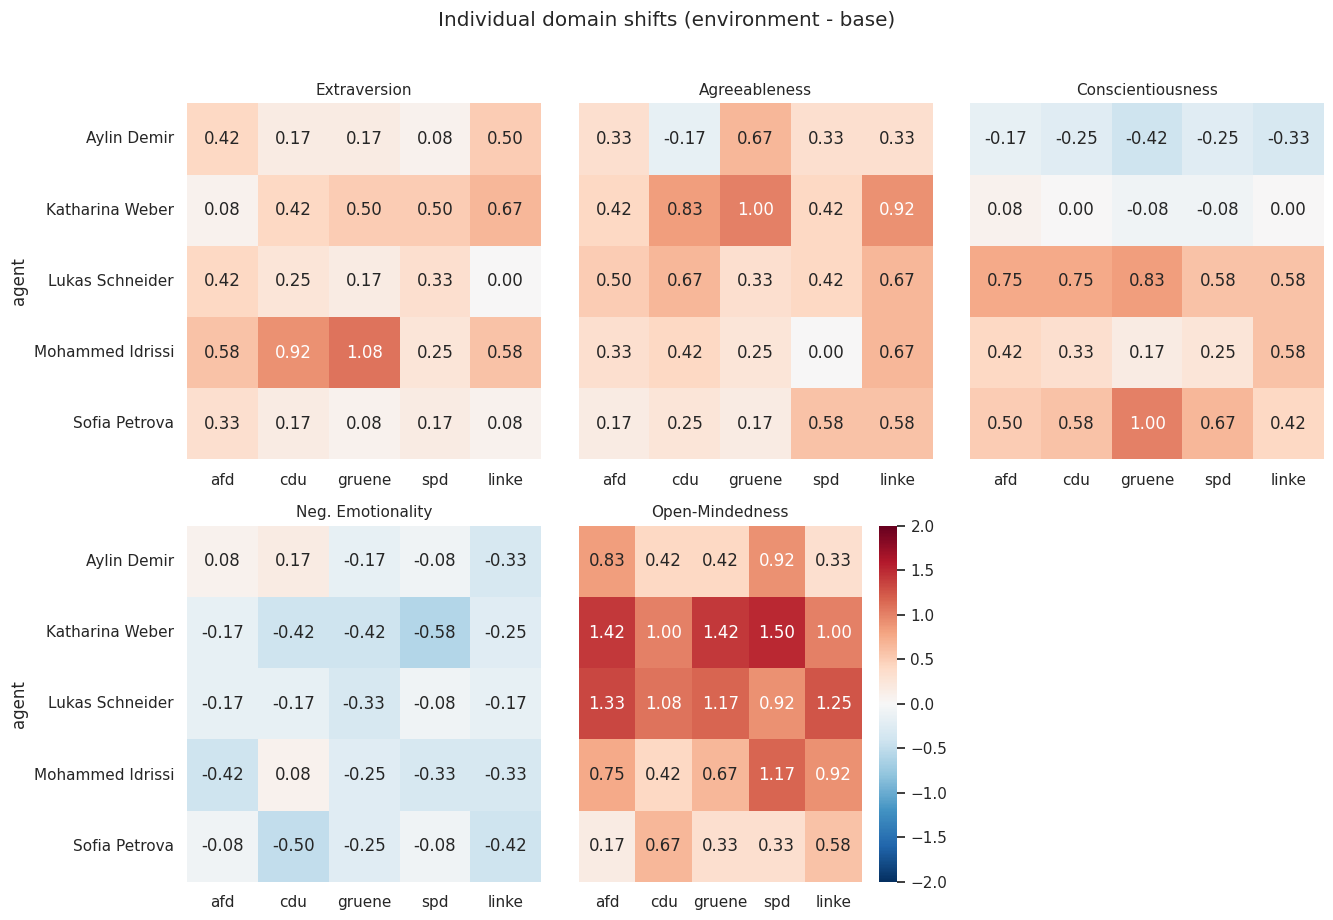

In [23]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Automatische Aufteilung auf 2 Zeilen
n_cols = math.ceil(len(DOMAINS) / 2)
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows), sharey=True)
axes = axes.flatten()

for i, domain in enumerate(DOMAINS):
    ax = axes[i]
    sub = shift_df[shift_df['measure'] == domain]
    pivot = sub.pivot(index='persona_name', columns='party', values='shift')
    pivot = pivot.reindex(columns=ENV_KEYS).loc[PERSONAS]
    
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        ax=ax, cbar=(i == len(DOMAINS) - 1), vmin=-2, vmax=2
    )
    ax.set_title(DOMAIN_LABELS[domain], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("agent" if i % n_cols == 0 else "")

# Überflüssige Axes ausblenden, falls Anzahl ungerade ist
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Individual domain shifts (environment - base)", y=1.02)
plt.tight_layout()
plt.show()


### 5.3 Spread of individual responses per environment

Boxplot/strip overlay of individual shifts per domain and environment shows
*how much agents disagree* even when the group mean shift is small — a wide
spread (or a bimodal strip pattern) signals the environment doesn't affect
everyone the same way.


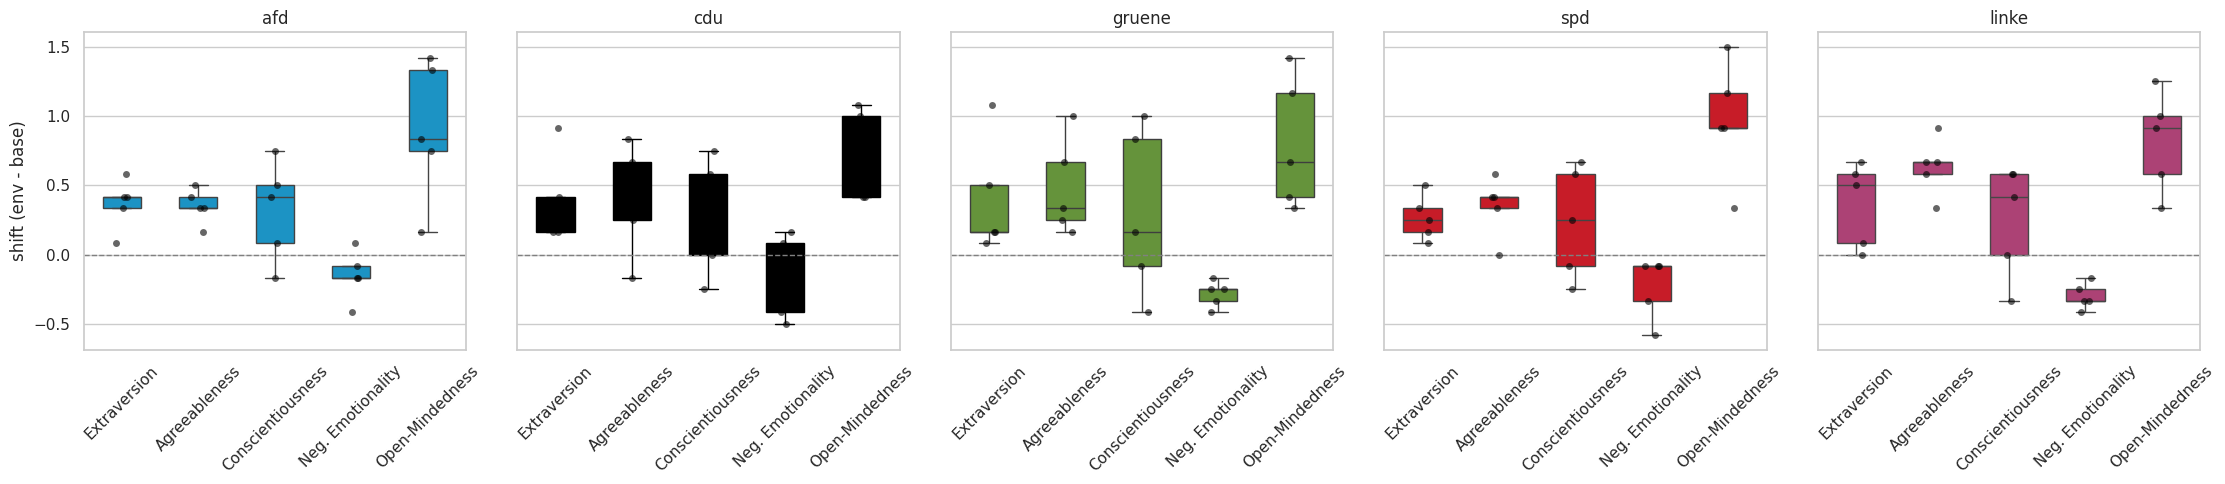

In [13]:
fig, axes = plt.subplots(1, len(ENV_KEYS), figsize=(4.5 * len(ENV_KEYS), 5), sharey=True)

for ax, env in zip(axes, ENV_KEYS):
    sub = shift_df[(shift_df['party'] == env) & (shift_df['level'] == 'domain')].copy()
    sub['domain_label'] = sub['measure'].map(DOMAIN_LABELS)
    sns.boxplot(
        data=sub, x='domain_label', y='shift', ax=ax,
        color=PARTY_COLORS[env], fliersize=0, width=0.5
    )
    sns.stripplot(
        data=sub, x='domain_label', y='shift', ax=ax,
        color='black', alpha=0.6, size=5, jitter=True
    )
    ax.axhline(0, color='grey', linewidth=1, linestyle='--')
    ax.set_title(env)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel("shift (env - base)")
plt.tight_layout()
plt.show()


## 6. Facet-level detail (optional deep dive)

The domain-level view above is the headline story; this section gives the
same group-mean radar but at the 15-facet resolution, in case specific
facets (e.g. *Trust*, *Assertiveness*) are of particular interest for your
party-program comparison.


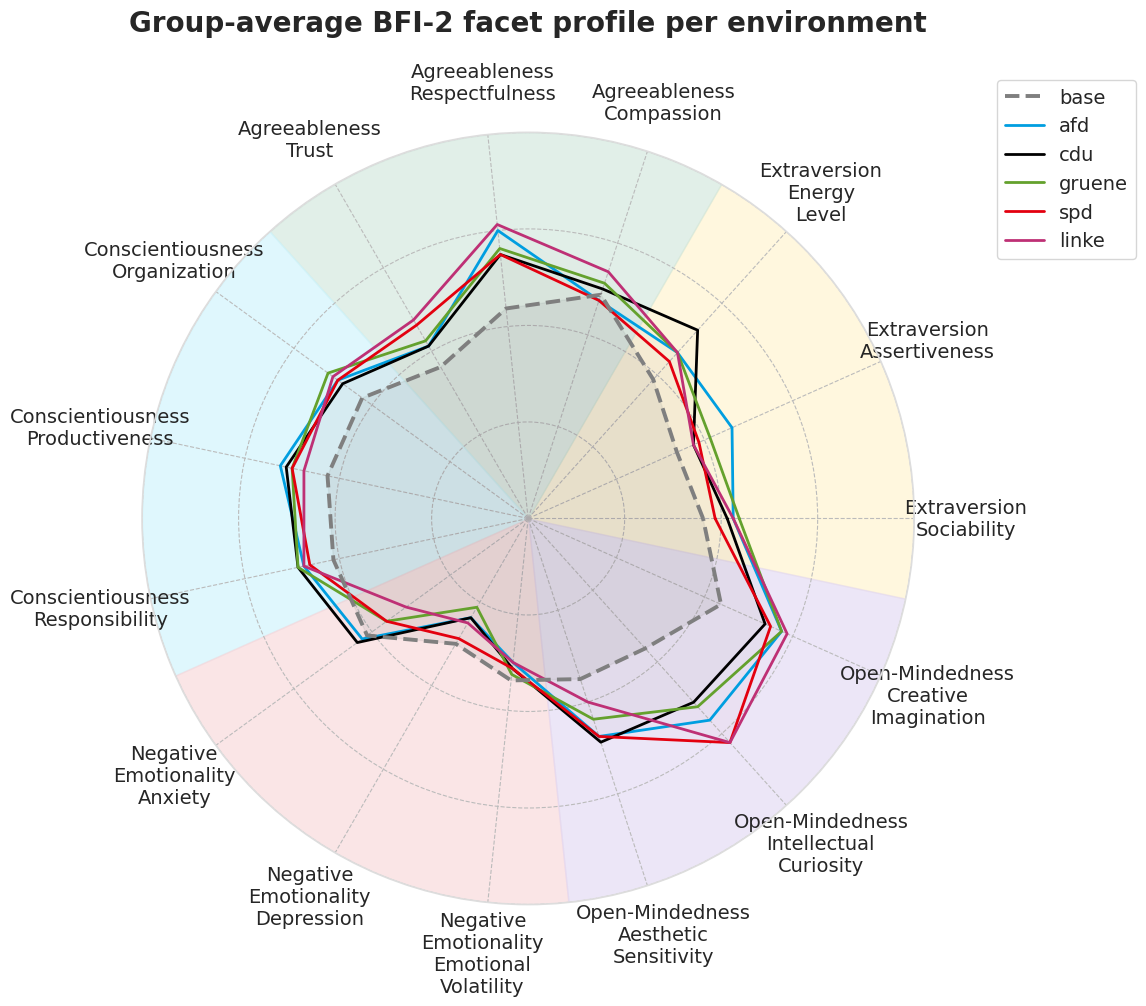

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def get_bfi_domain(facet_name):
    """Robustly extracts the BFI-2 domain name regardless of prefixes."""
    f = facet_name.lower()
    if 'extraversion' in f:
        return 'Extraversion'
    elif 'agreeab' in f:
        return 'Agreeableness'
    elif 'conscient' in f:
        return 'Conscientiousness'
    elif 'negative' in f or 'neurot' in f:
        return 'Negative Emotionality'
    elif 'open' in f or 'mind' in f:
        return 'Open-Mindedness'
    return facet_name.split('_')[0].title()

DOMAIN_PASTEL_COLORS = {
    'Extraversion': '#FFF3CD',           # Soft Yellow/Orange
    'Agreeableness': '#D1E7DD',          # Soft Green
    'Conscientiousness': '#CFF4FC',       # Soft Blue
    'Negative Emotionality': '#F8D7DA',   # Soft Pink/Red
    'Open-Mindedness': '#E2D9F3',        # Soft Purple
}

def clean_radar_plot(categories, series_dict, colors, facets_list, title=""):
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles_closed = angles + [angles[0]]
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    
    # 1. Domain Background Sectors (Layer 0)
    domains = [get_bfi_domain(f) for f in facets_list]
    d_angle = 2 * np.pi / num_vars
    half_step = d_angle / 2.0
    
    i = 0
    while i < len(domains):
        current_domain = domains[i]
        start_idx = i
        while i < len(domains) and domains[i] == current_domain:
            i += 1
        end_idx = i - 1
        
        start_angle = angles[start_idx] - half_step
        end_angle = angles[end_idx] + half_step
        
        theta_sector = np.linspace(start_angle, end_angle, 100)
        bg_color = DOMAIN_PASTEL_COLORS.get(current_domain, '#F0F0F0')
        
        ax.fill_between(
            theta_sector, 1, 5, 
            color=bg_color, 
            alpha=0.65, 
            zorder=0
        )

    # 2. Axis limits & grid setup
    ax.set_ylim(1, 5)
    ax.set_yticks([2, 3, 4, 5])
    ax.set_yticklabels([])  # <--- Removes inner numbers completely
    
    ax.grid(color='#bbbbbb', linestyle='--', linewidth=0.8, zorder=1)
    ax.spines['polar'].set_color('#dddddd')
    
    # 3. Plot Party Lines (Layers 2 & 3)
    for name, values in series_dict.items():
        val_closed = np.append(values, values[0])
        is_base = (name == 'base')
        
        color = colors.get(name, '#333333')
        linestyle = '--' if is_base else '-'
        linewidth = 2.8 if is_base else 2.0
        
        ax.plot(angles_closed, val_closed, label=name, color=color, 
                linestyle=linestyle, linewidth=linewidth, zorder=3 if is_base else 2)
        
        fill_alpha = 0.10 if is_base else 0.01
        ax.fill(angles_closed, val_closed, color=color, alpha=fill_alpha, zorder=1)

    # 4. Outer Category Labels Setup
    ax.set_xticks(angles)
    ax.set_xticklabels(categories, size=14, fontweight='medium')
    ax.tick_params(axis='x', pad=24)
    
    # 5. Foreground Category Labels (Layer 10)
    for label in ax.get_xticklabels():
        label.set_zorder(10)
    
    # Title & Legend
    plt.title(title, y=1.12, fontsize=20, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.30, 1.08), frameon=True, fontsize=14)
    
    return fig, ax

# --- Execution ---
facet_categories = [
    f.split('_', 1)[1].replace('_', '\n') if '_' in f else f
    for f in FACETS
]

facet_group_means = (
    long_df[long_df['party'].isin([BASE_KEY] + ENV_KEYS)]
    .query("persona_name != 'Katharina Weber'")
    .groupby('party')[FACETS]
    .mean()
    .reindex([BASE_KEY] + ENV_KEYS)
)

facet_series = {
    run: facet_group_means.loc[run, FACETS].values
    for run in facet_group_means.index
}

clean_radar_plot(
    facet_categories, 
    facet_series, 
    colors=PARTY_COLORS,
    facets_list=FACETS,
    title="Group-average BFI-2 facet profile per environment"
)
plt.tight_layout()
plt.show()

## 7. Export results

Saves the tidy shift table and the group-level statistics to CSV, and the
figures already displayed above can be saved the same way by calling
`fig.savefig(...)` right after any of the plotting cells if you want to keep
specific ones.


In [24]:
os.makedirs('outputs', exist_ok=True)

shift_df.to_csv('outputs/agent_shifts_long.csv', index=False)
group_stats.to_csv('outputs/group_level_stats.csv', index=False)
group_means.to_csv('outputs/group_mean_domain_scores.csv')

print("Saved:")
print(" - outputs/agent_shifts_long.csv   (per-agent, per-domain/facet shifts)")
print(" - outputs/group_level_stats.csv   (paired t-test / Wilcoxon / Cohen's d per domain x env)")
print(" - outputs/group_mean_domain_scores.csv")


Saved:
 - outputs/agent_shifts_long.csv   (per-agent, per-domain/facet shifts)
 - outputs/group_level_stats.csv   (paired t-test / Wilcoxon / Cohen's d per domain x env)
 - outputs/group_mean_domain_scores.csv
